# ResStock 2025 R1 - Electrification Impact & Upgrade Prioritization
ResStock provides a sample weight for each row which indicates how many homes that row represents. Every number reported here should be weighted accordingly.

## Setup
Paths, upgrade IDs, one loader, and weighted-stat helpers reused throughout.

In [ ]:
import numpy as np
import pandas as pd
import s3fs
import pyarrow.dataset as pads
import matplotlib.pyplot as plt
import seaborn as sns
import json

# S3 link to get the baseline data file
S3_PATH = (
    "s3://oedi-data-lake/nrel-pds-building-stock/"
    "end-use-load-profiles-for-us-building-stock/2025/"
    "resstock_amy2018_release_1/metadata_and_annual_results/"
    "national/full/parquet/upgrade0.parquet"
)

COST_COL = "out.utility_bills.total_bill..usd"
INCOME_COL = "in.representative_income"
BURDEN_COL = "out.energy_burden..percentage"
SITE = "out.site_energy.total.energy_consumption..kwh"
ELEC = "out.electricity.total.energy_consumption..kwh"
W = "weight"

FS = s3fs.S3FileSystem(anon=True)
ELECTRIFICATION_UPGRADES = [4, 6, 7, 8, 9, 19, 20, 21, 22, 23]   # set from release README
ALL_UPGRADES = list(range(1, 32))         # set from release README

# json originally provided by NREL with ResStock release
UPGRADE_NAMES = json.loads("""{
  "0": "Baseline",
  "1": "Natural Gas Furnace 95% AFUE for All Dwellings with Ducts",
  "2": "Propane or Fuel Oil Furnace 95% AFUE",
  "3": "Minimum Efficiency Boilers, Furnaces, and Air Conditioners Circa 2025",
  "4": "Typical Cold Climate Ducted Air Source Heat Pump with Detailed Performance Data",
  "5": "Dual Fuel Heating System",
  "6": "Single-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes",
  "7": "Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes",
  "8": "Variable-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes",
  "9": "Heat Pumps Water Heater",
  "10": "High Efficiency Natural Gas Tankless Water Heater",
  "11": "Air Sealing",
  "12": "Attic Floor Insulation for Unfinished Attics",
  "13": "Duct Sealing and Insulation",
  "14": "Drill and Fill Wall Insulation with Air Sealing",
  "15": "Air Sealing + Attic Floor Insulation + Duct sealing",
  "16": "Air Sealing + Attic Floor Insulation + Duct sealing + Drill and Fill Wall Insulation",
  "17": "EnergyStar Windows",
  "18": "Package - Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes with Air Sealing with Attic Floor Insulation with Duct Sealing",
  "19": "Electric Vehicle Adoption with Level 1 Charging",
  "20": "Electric Vehicle Adoption with Level 2 Charging",
  "21": "Efficient Electric Vehicle Adoption with Level 2 Charging",
  "22": "Electric Vehicle Adoption with Level 2 Charging and Demand Flexibility",
  "23": "Efficient Electric Vehicle Adoption with Level 2 Charging and Demand Flexibility",
  "24": "HVAC Demand Flexibility - On-peak Load Shedding, 2F Offset",
  "25": "HVAC Demand Flexibility - Pre-peak Load Shifting, 2F Offset, 4hr Pre-peak Duration",
  "26": "HVAC Demand Flexibility - On-peak Load Shedding, 4F Offset",
  "27": "HVAC Demand Flexibility - Pre-peak Load Shifting, 4F Offset, 4hr Pre-peak Duration",
  "28": "HVAC Demand Flexibility - Pre-peak Load Shifting, 2F Offset, 1hr Pre-peak Duration",
  "29": "General Air Sealing",
  "30": "General Air Sealing, Attic Floor Insulation, and Duct Sealing",
  "31": "Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes, General Air Sealing, Attic Floor Insulation, and Duct Sealing",
  "32": "Variable-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes, General Air Sealing, Attic Floor Insulation, and Duct Sealing"
}""")

def upgrade_path(u):
    return S3_PATH.replace("upgrade0", f"upgrade{u}")


def load(u, columns):
    dset = pads.dataset(upgrade_path(u), filesystem=FS)
    cols = [x for x in columns if x in dset.schema.names]
    missing = set(columns) - set(cols)
    if missing:
        print(f"upgrade{u}: skipping missing cols {sorted(missing)[:5]}")
    df = dset.to_table(columns=cols).to_pandas()
    return df.reset_index() if "bldg_id" not in df.columns else df


def wmean(v, w):
    m = v.notna() & w.notna()
    return np.average(v[m], weights=w[m]) if m.any() else np.nan


def wmedian(v, w):
    d = pd.DataFrame({"v": v, "w": w}).dropna().sort_values("v")
    if d.empty:
        return np.nan
    cum = d["w"].cumsum()
    return d.loc[cum >= cum.iloc[-1] / 2, "v"].iloc[0]


def wshare(mask, w):
    return wmean(mask.astype(float), w)

In [ ]:
# readable names for upgrades
SHORT = {
    1: "Gas furnace 95%", 2: "Propane/oil furnace 95%", 3: "Min-eff HVAC 2025",
    4: "Cold-climate ASHP", 5: "Dual-fuel HP", 6: "Geo HP (1-spd)", 7: "Geo HP (2-spd)",
    8: "Geo HP (var-spd)", 9: "HP water heater", 10: "Gas tankless WH",
    11: "Air sealing", 12: "Attic insulation", 13: "Duct seal+insul",
    14: "Wall insul + air seal", 15: "Envelope pkg (basic)", 16: "Envelope pkg (full)",
    17: "ENERGY STAR windows", 18: "Geo HP + envelope", 19: "EV (L1)", 20: "EV (L2)",
    21: "Efficient EV (L2)", 22: "EV (L2, flex)", 23: "Efficient EV (L2, flex)",
    24: "HVAC flex shed 2F", 25: "HVAC flex shift 2F/4h", 26: "HVAC flex shed 4F",
    27: "HVAC flex shift 4F/4h", 28: "HVAC flex shift 2F/1h",
    29: "General air sealing", 30: "Air seal + attic + duct",
    31: "Geo HP (2-spd) + envelope", 32: "Geo HP (var-spd) + envelope",
}
AMI_ORDER = ["0-30%", "30-60%", "60-80%", "80-100%", "100-120%", "120-150%", "150%+"]


def short_name(u):
    return SHORT.get(int(float(u)), str(u))

## Phase 1 — Load baseline, hygiene, and segments
Load once with sample weights; keep vacant units for stock energy but flag them out of income/burden analyses.

In [ ]:
# saving only columns relevant to energy cost/consumption, geographics, demographics
COLS = ["bldg_id", W,
    "in.geometry_building_type_recs", "in.vintage", "in.sqft..ft2",
    "in.ashrae_iecc_climate_zone_2004", "in.state", "in.census_region", "in.census_division",
    "in.heating_fuel", "in.water_heater_fuel", "in.cooking_range", "in.clothes_dryer",
    "in.hvac_secondary_heating_fuel", "in.tenure", "in.vacancy_status",
    "in.area_median_income", "in.federal_poverty_level", "in.has_pv",
    SITE, ELEC,
    "out.natural_gas.total.energy_consumption..kwh",
    "out.fuel_oil.total.energy_consumption..kwh",
    "out.propane.total.energy_consumption..kwh",
    COST_COL, INCOME_COL, BURDEN_COL]

base = load(0, COLS)
base["in.sqft..ft2"] = pd.to_numeric(base["in.sqft..ft2"], errors="coerce")
base[INCOME_COL] = pd.to_numeric(base[INCOME_COL], errors="coerce")
base["occupied"] = base["in.vacancy_status"].eq("Occupied") if "in.vacancy_status" in base else True
base["valid_income"] = base["occupied"] & (base[INCOME_COL] > 0)
base["size_bin"] = pd.qcut(base["in.sqft..ft2"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

print(base.shape)
print("weighted homes (M):", round(base[W].sum() / 1e6, 1))
print("occupied share:", round(wshare(base["occupied"], base[W]), 3))

(549971, 30)
weighted homes (M): 139.6
occupied share: 0.879


### Fuel classification (thermal end uses only)
Classify on heating, water heating, cooking, and drying; wood/other fuels get a separate flag instead of being folded into Mixed.

In [ ]:
FOSSIL = ("Natural Gas", "Fuel Oil", "Propane", "Gas")
OTHER = ("Wood", "Pellet", "Coal", "Other Fuel")
END_USES = ["in.heating_fuel", "in.water_heater_fuel", "in.cooking_range", "in.clothes_dryer"]


def fuel_of(x):
    s = "" if pd.isna(x) else str(x)
    if any(k in s for k in FOSSIL):
        return "fossil"
    if any(k in s for k in OTHER):
        return "other"
    return "electric_or_none"  # 'None' (absent end use) is not a fossil end use


eu = base[END_USES].apply(lambda col: col.map(fuel_of))
n_fossil = eu.eq("fossil").sum(axis=1)
heat_fossil = eu["in.heating_fuel"].eq("fossil")
wh_fossil = eu["in.water_heater_fuel"].eq("fossil")

base["fuel_class"] = np.select(
    [n_fossil.eq(0) & eu.eq("other").sum(axis=1).eq(0),
     heat_fossil & wh_fossil],
    ["All-Electric", "Fossil-Conventional"],
    default="Mixed-Fuel")
base["uses_wood_other"] = eu.eq("other").any(axis=1)

pd.DataFrame({
    "weighted_homes_M": base.groupby("fuel_class")[W].sum() / 1e6,
    "share": base.groupby("fuel_class")[W].sum() / base[W].sum(),
}).round(3)

,weighted_homes_M,share
fuel_class,,
All-Electric,41.610,0.298
Fossil-Conventional,62.972,0.451
Mixed-Fuel,35.057,0.251


### Weighted stock composition (EDA)
Composition described in weighted (stock) terms, not sample counts.

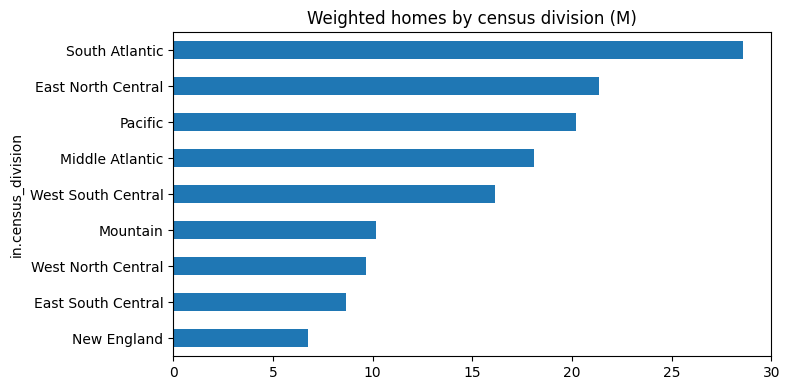

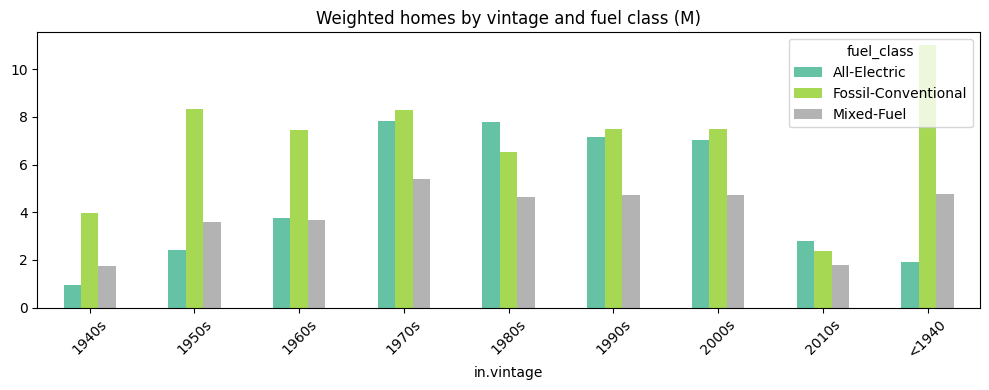

In [ ]:
# First visualization: Weighted homes by census division
fig1, ax1 = plt.subplots(figsize=(8, 4))
(base.groupby("in.census_division")[W].sum().div(1e6)
     .sort_values().plot.barh(ax=ax1, color="tab:blue"))
ax1.set_title("Weighted homes by census division (M)")
plt.tight_layout()
plt.show()

# Second visualization: Weighted homes by vintage and fuel class (unstacked)
fig2, ax2 = plt.subplots(figsize=(10, 4))
(base.groupby(["in.vintage", "fuel_class"])[W].sum().div(1e6).unstack()
     .loc[sorted(base["in.vintage"].dropna().unique())]
     .plot.bar(stacked=False, ax=ax2, colormap="Set2"))
ax2.set_title("Weighted homes by vintage and fuel class (M)")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


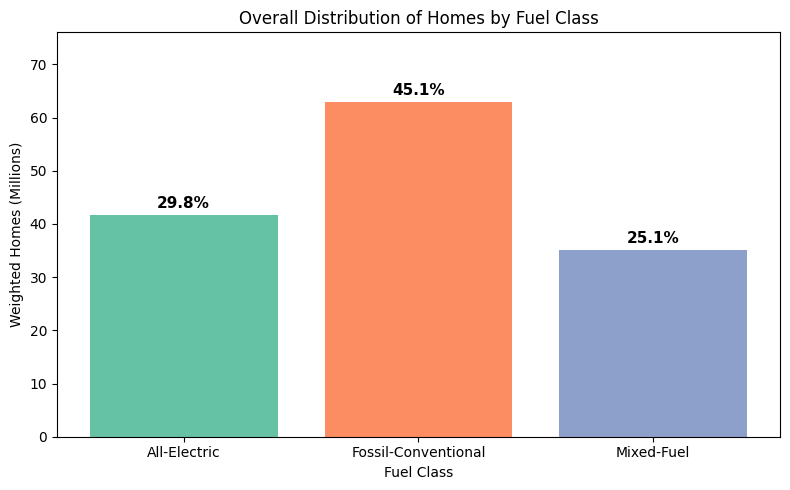

In [ ]:
import matplotlib.pyplot as plt

# Calculate the total weighted homes per fuel class
fuel_dist = base.groupby('fuel_class')[W].sum()

# Calculate the percentages
fuel_pct = fuel_dist / fuel_dist.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Plot the bars (values in millions for readability)
bars = ax.bar(fuel_dist.index, fuel_dist.values / 1e6, color=['#66c2a5', '#fc8d62', '#8da0cb'])

ax.set_title('Overall Distribution of Homes by Fuel Class')
ax.set_ylabel('Weighted Homes (Millions)')
ax.set_xlabel('Fuel Class')

# Add percentage labels above the bars
for bar, pct in zip(bars, fuel_pct):
    height = bar.get_height()
    ax.annotate(f'{pct:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Expand y-axis limit slightly to make room for annotations
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()


### Confounder check (EDA)
How differently the three fuel classes are distributed across climate, size, income, and PV — the confounding that raw class comparisons absorb.

,median_sqft,median_income,share_pv,share_cold_cz
fuel_class,,,,
All-Electric,1228.0,53635.0,0.005,0.159
Fossil-Conventional,1678.0,73400.0,0.013,0.466
Mixed-Fuel,1228.0,64180.0,0.011,0.348


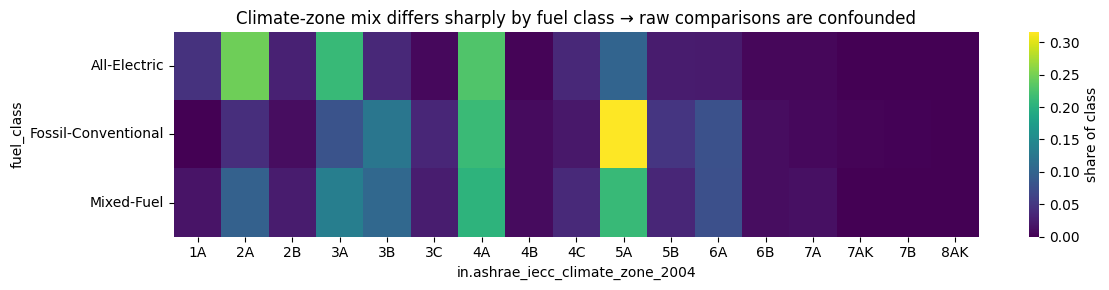

In [ ]:
balance = pd.DataFrame({
    "median_sqft": base.groupby("fuel_class").apply(lambda d: wmedian(d["in.sqft..ft2"], d[W]), include_groups=False),
    "median_income": base[base.valid_income].groupby("fuel_class").apply(lambda d: wmedian(d[INCOME_COL], d[W]), include_groups=False),
    "share_pv": base.groupby("fuel_class").apply(lambda d: wshare(d["in.has_pv"].eq("Yes"), d[W]), include_groups=False),
    "share_cold_cz": base.groupby("fuel_class").apply(
        lambda d: wshare(d["in.ashrae_iecc_climate_zone_2004"].astype(str).str[0].isin(list("5678")), d[W]),
        include_groups=False),
})
display(balance.round(3))

cz_mix = base.groupby(["fuel_class", "in.ashrae_iecc_climate_zone_2004"])[W].sum().unstack(fill_value=0)
cz_mix = cz_mix.div(cz_mix.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(cz_mix, cmap="viridis", ax=ax, cbar_kws={"label": "share of class"})
ax.set_title("Climate-zone mix differs sharply by fuel class → raw comparisons are confounded")
plt.tight_layout(); plt.show()

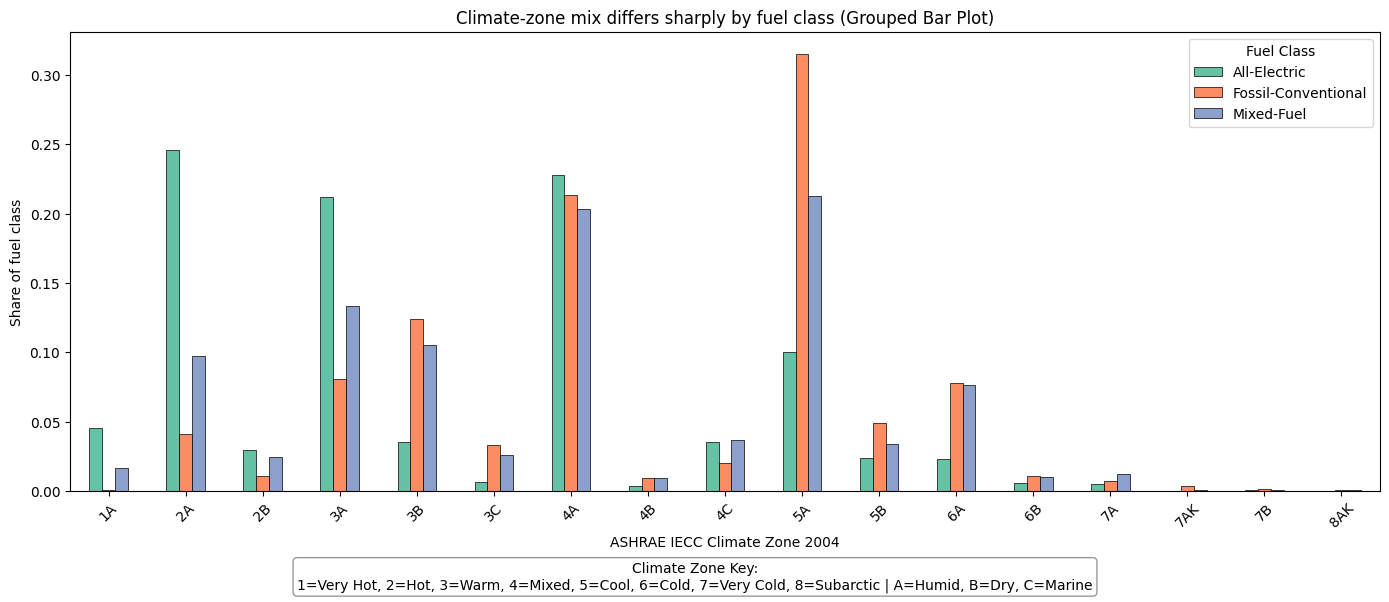

In [ ]:
import matplotlib.pyplot as plt

# Recalculate cz_mix to ensure it's available
cz_mix = base.groupby(["fuel_class", "in.ashrae_iecc_climate_zone_2004"])[W].sum().unstack(fill_value=0)
cz_mix = cz_mix.div(cz_mix.sum(axis=1), axis=0)

# Transpose the dataframe so climate zones are on the x-axis
fig, ax = plt.subplots(figsize=(14, 6))
# Use the same color scheme as the other fuel class bar plots
cz_mix.T.plot.bar(ax=ax, color=['#66c2a5', '#fc8d62', '#8da0cb'], edgecolor="black", linewidth=0.5)

ax.set_title("Climate-zone mix differs sharply by fuel class (Grouped Bar Plot)")
ax.set_ylabel("Share of fuel class")
ax.set_xlabel("ASHRAE IECC Climate Zone 2004")
ax.tick_params(axis="x", rotation=45)
plt.legend(title="Fuel Class")

# Add concise legend explaining climate zones
cz_text = (
    "Climate Zone Key:\n"
    "1=Very Hot, 2=Hot, 3=Warm, 4=Mixed, 5=Cool, 6=Cold, 7=Very Cold, 8=Subarctic | A=Humid, B=Dry, C=Marine"
)
plt.figtext(0.5, 0.01, cz_text, ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8))

# Adjust layout to make room for the text at the bottom
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


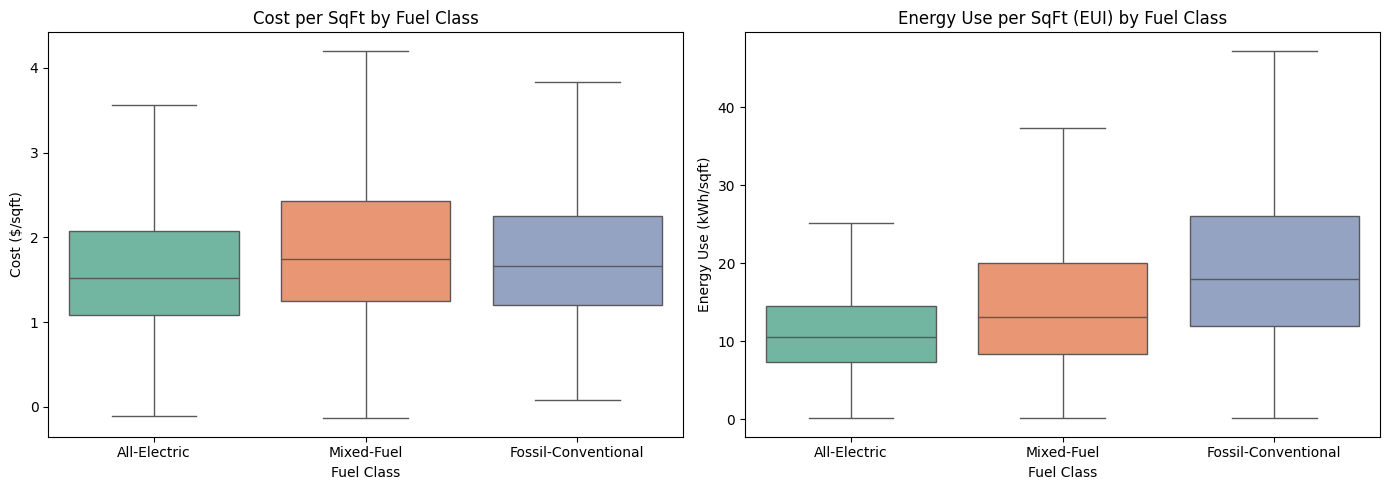

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate metrics per square foot
base['cost_per_sqft'] = base[COST_COL] / base['in.sqft..ft2']
base['eui_kwh_sqft'] = base[SITE] / base['in.sqft..ft2']

# Prepare data and drop NaNs to avoid sampling errors
plot_data = base[['fuel_class', 'cost_per_sqft', 'eui_kwh_sqft', W]].dropna()

# Standard boxplots do not support weights.
# We create a representative weighted sample to draw the boxplots.
sampled_data = plot_data.sample(n=100_000, weights=W, replace=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost per sqft
sns.boxplot(data=sampled_data, x='fuel_class', y='cost_per_sqft', ax=axes[0],
            hue='fuel_class', palette='Set2', showfliers=False, legend=False) # Hide extreme outliers for readability
axes[0].set_title('Cost per SqFt by Fuel Class')
axes[0].set_ylabel('Cost ($/sqft)')
axes[0].set_xlabel('Fuel Class')

# Plot 2: EUI (kWh per sqft)
sns.boxplot(data=sampled_data, x='fuel_class', y='eui_kwh_sqft', ax=axes[1],
            hue='fuel_class', palette='Set2', showfliers=False, legend=False)
axes[1].set_title('Energy Use per SqFt (EUI) by Fuel Class')
axes[1].set_ylabel('Energy Use (kWh/sqft)')
axes[1].set_xlabel('Fuel Class')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


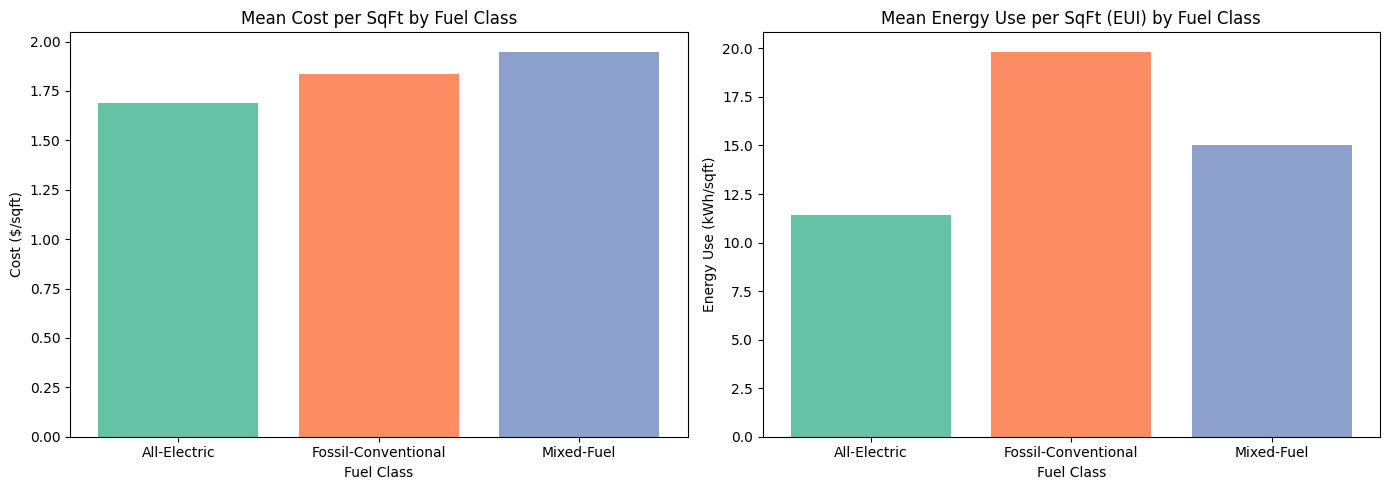

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure cost_per_sqft and eui_kwh_sqft are calculated
if 'cost_per_sqft' not in base.columns:
    base['cost_per_sqft'] = base[COST_COL] / base['in.sqft..ft2']
if 'eui_kwh_sqft' not in base.columns:
    base['eui_kwh_sqft'] = base[SITE] / base['in.sqft..ft2']

# Calculate weighted means for the bar charts
bar_data = base.groupby('fuel_class', observed=True).apply(
    lambda d: pd.Series({
        'cost_per_sqft_wmean': wmean(d['cost_per_sqft'], d[W]),
        'eui_kwh_sqft_wmean': wmean(d['eui_kwh_sqft'], d[W])
    }), include_groups=False
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use similar colors as the Set2 palette used in the boxplots
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

# Plot 1: Cost per sqft (Bar)
axes[0].bar(bar_data['fuel_class'], bar_data['cost_per_sqft_wmean'], color=colors)
axes[0].set_title('Mean Cost per SqFt by Fuel Class')
axes[0].set_ylabel('Cost ($/sqft)')
axes[0].set_xlabel('Fuel Class')

# Plot 2: EUI (kWh per sqft) (Bar)
axes[1].bar(bar_data['fuel_class'], bar_data['eui_kwh_sqft_wmean'], color=colors)
axes[1].set_title('Mean Energy Use per SqFt (EUI) by Fuel Class')
axes[1].set_ylabel('Energy Use (kWh/sqft)')
axes[1].set_xlabel('Fuel Class')

for ax in axes:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


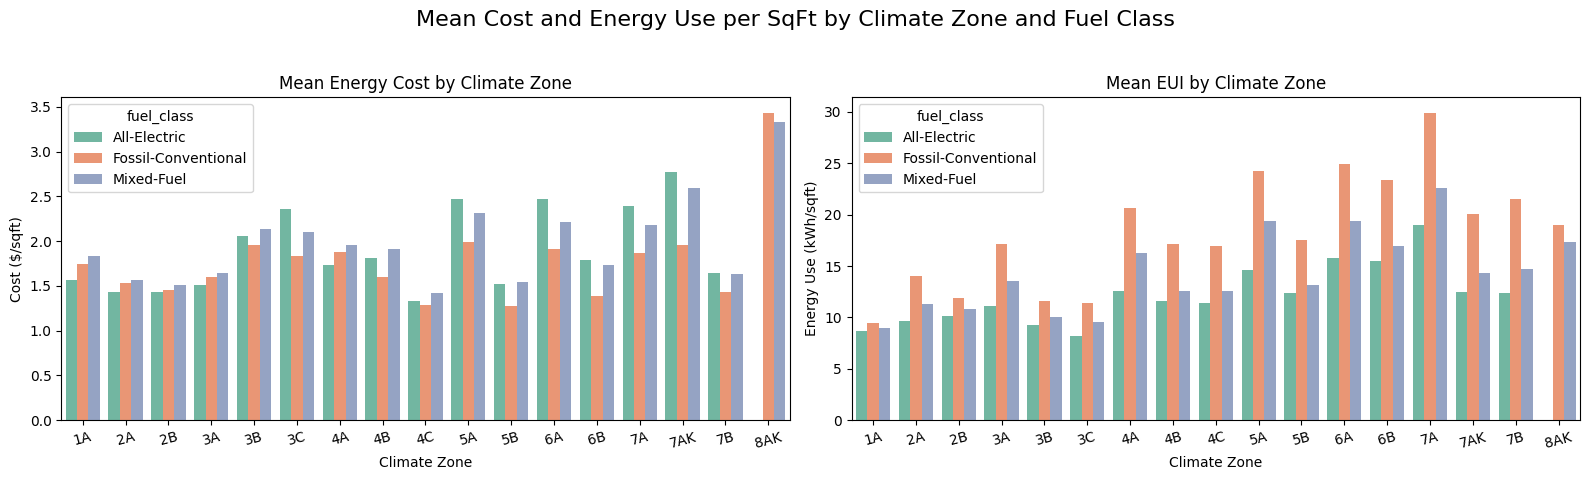

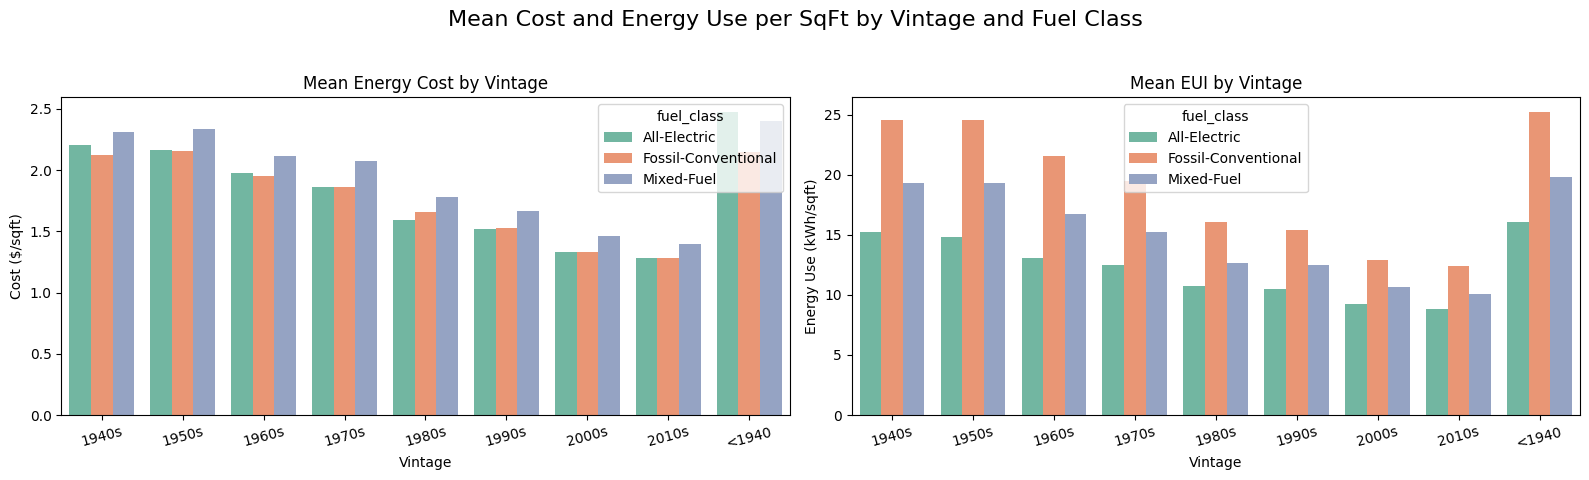

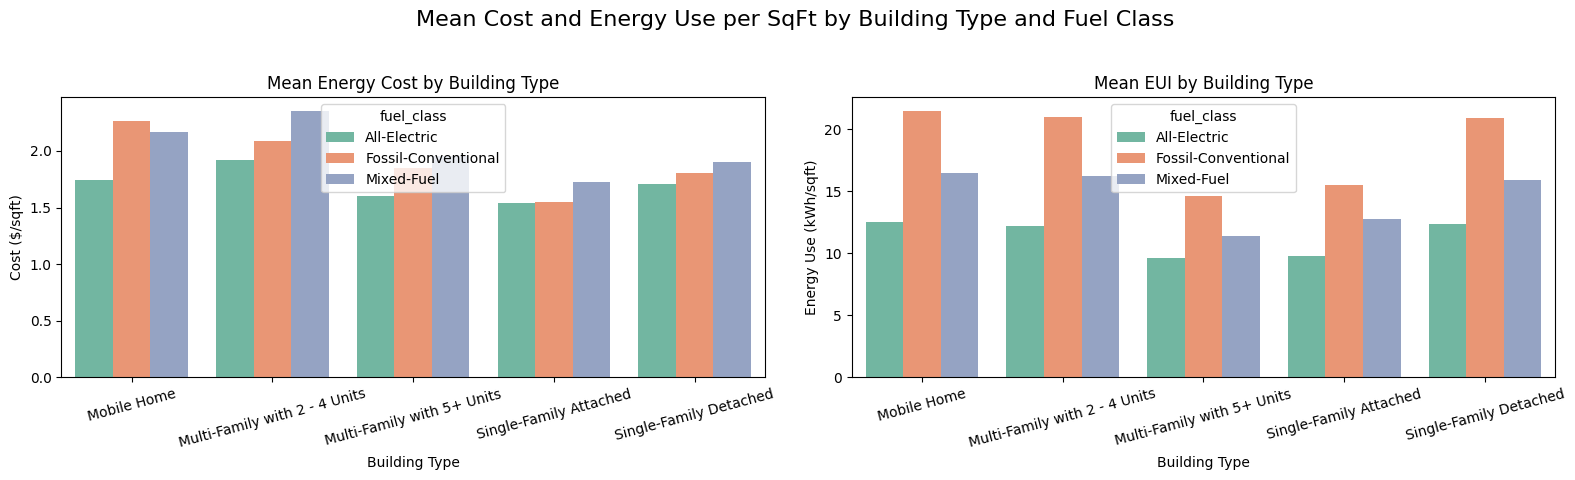

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the variables to stratify by and their readable titles
strat_vars = {
    'in.ashrae_iecc_climate_zone_2004': 'Climate Zone',
    'in.vintage': 'Vintage',
    'in.geometry_building_type_recs': 'Building Type'
}

# Loop over each stratification variable to generate a 1x2 plot grid
for var, title_name in strat_vars.items():

    # Calculate  means for the bar charts, now grouping by var and fuel_class
    bar_data = base.groupby([var, 'fuel_class'], observed=True).apply(
        lambda d: pd.Series({
            'cost_wmean': wmean(d['cost_per_sqft'], d[W]),
            'eui_wmean': wmean(d['eui_kwh_sqft'], d[W])
        }), include_groups=False
    ).reset_index()

    # Determine the order of categories for consistent x-axis plotting
    order = sorted(base[var].dropna().unique())

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Mean Cost and Energy Use per SqFt by {title_name} and Fuel Class', fontsize=16)

    # -- Bar Plots (Means) --
    sns.barplot(data=bar_data, x=var, y='cost_wmean', hue='fuel_class', ax=axes[0], order=order, palette='Set2')
    axes[0].set_title(f'Mean Energy Cost by {title_name}')
    axes[0].set_ylabel('Cost ($/sqft)')

    sns.barplot(data=bar_data, x=var, y='eui_wmean', hue='fuel_class', ax=axes[1], order=order, palette='Set2')
    axes[1].set_title(f'Mean EUI by {title_name}')
    axes[1].set_ylabel('Energy Use (kWh/sqft)')

    # Apply uniform formatting to x-axis labels
    for ax in axes:
        ax.set_xlabel(title_name)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=15, ha='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Make room for the main title
    plt.show()


## Phase 2 — Electrification impact
Descriptive weighted segments, then two confounding controls (joint stratification and regression adjustment), then the preferred estimate: same-home counterfactuals.

In [ ]:
# Descriptive weighted comparison within segments
seg = ["in.geometry_building_type_recs", "in.ashrae_iecc_climate_zone_2004", "fuel_class"]
matched = (base.groupby(seg, observed=True)
           .apply(lambda d: pd.Series({
               "weighted_homes": d[W].sum(),
               "site_kwh_wmedian": wmedian(d[SITE], d[W]),
               "bill_usd_wmedian": wmedian(d[COST_COL], d[W])}), include_groups=False)
           .reset_index())
matched.head(12)

,in.geometry_building_type_recs,in.ashrae_iecc_climate_zone_2004,fuel_class,weighted_homes,site_kwh_wmedian,bill_usd_wmedian
0,Mobile Home,1A,All-Electric,3.605432e+04,11329.541432,1780.65
1,Mobile Home,1A,Mixed-Fuel,1.117176e+04,13552.485499,2112.41
2,Mobile Home,2A,All-Electric,1.226609e+06,12259.162866,1782.55
3,Mobile Home,2A,Fossil-Conventional,4.697218e+04,17781.207971,2216.95
4,Mobile Home,2A,Mixed-Fuel,3.125554e+05,13567.139053,1920.43
5,Mobile Home,2B,All-Electric,1.411704e+05,13453.427478,1891.11
6,Mobile Home,2B,Fossil-Conventional,4.468705e+04,15438.983978,1937.11
7,Mobile Home,2B,Mixed-Fuel,6.144469e+04,14914.679834,2127.12
8,Mobile Home,3A,All-Electric,1.402818e+06,14110.785888,1877.14
9,Mobile Home,3A,Fossil-Conventional,1.447251e+05,18757.427706,2004.68


In [ ]:
# Joint stratification: within-cell gaps averaged over a common weight base
CELL = ["in.geometry_building_type_recs", "in.ashrae_iecc_climate_zone_2004", "in.vintage", "size_bin"]
cells = (base.groupby(CELL + ["fuel_class"], observed=True)
         .apply(lambda d: pd.Series({"w": d[W].sum(),
                                     "site": wmedian(d[SITE], d[W]),
                                     "bill": wmedian(d[COST_COL], d[W])}), include_groups=False)
         .reset_index())
wide = cells.pivot_table(index=CELL, columns="fuel_class", values=["site", "bill"], observed=True)
w_cell = cells.pivot_table(index=CELL, columns="fuel_class", values="w", observed=True)

MIN_W = 50_000  # every class must have enough weighted homes in the cell
ok = w_cell.ge(MIN_W).all(axis=1)
wide, w_common = wide[ok], w_cell[ok].min(axis=1)

gaps = pd.DataFrame({
    "site_kwh_gap_fossil_vs_elec": wide[("site", "Fossil-Conventional")] - wide[("site", "All-Electric")],
    "bill_gap_fossil_vs_elec": wide[("bill", "Fossil-Conventional")] - wide[("bill", "All-Electric")],
    "site_kwh_gap_mixed_vs_elec": wide[("site", "Mixed-Fuel")] - wide[("site", "All-Electric")],
})
print(f"{ok.sum()} comparable cells covering {w_common.sum()/1e6:.1f}M weighted homes (per class)")
gaps.apply(lambda col: pd.Series({"wmean_gap": wmean(col, w_common),
                                  "wmedian_gap": wmedian(col, w_common)})).round(0)

108 comparable cells covering 11.8M weighted homes (per class)


,site_kwh_gap_fossil_vs_elec,bill_gap_fossil_vs_elec,site_kwh_gap_mixed_vs_elec
wmean_gap,9573.0,-185.0,4050.0
wmedian_gap,8816.0,-23.0,3233.0


below viz didn't come out like I wanted

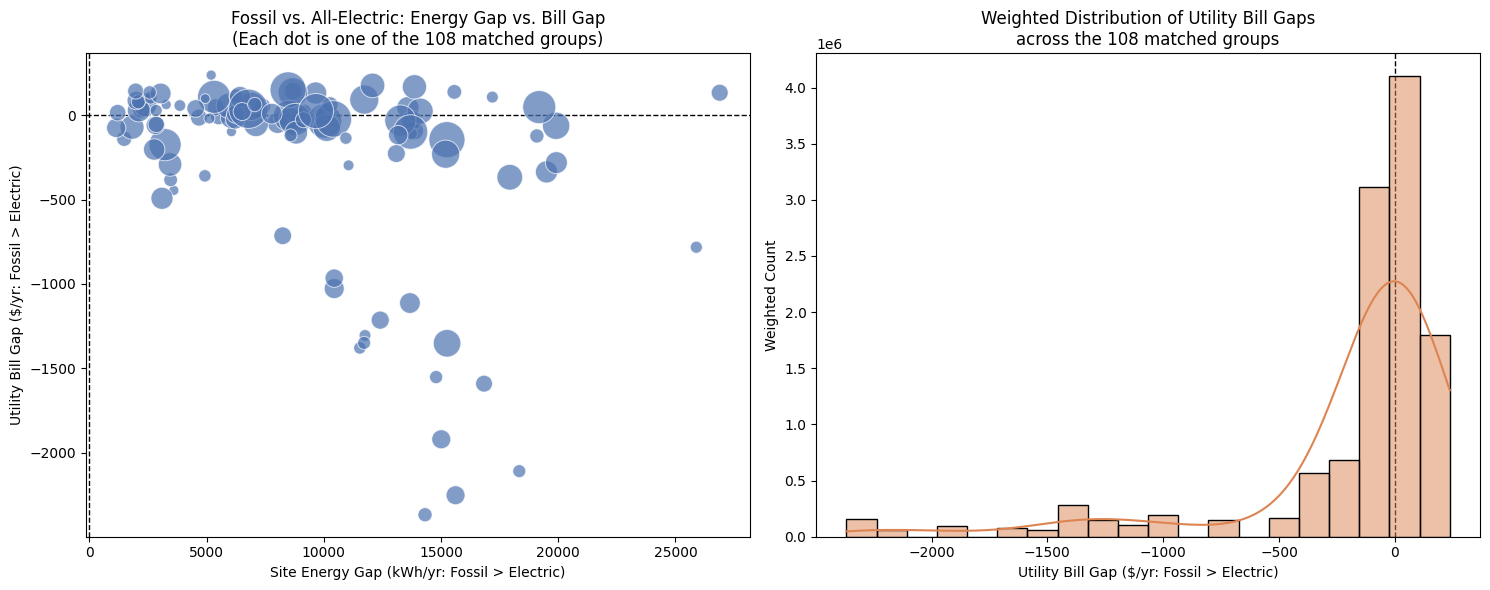

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine gaps and weights for plotting
plot_data = gaps.copy()
plot_data['weight'] = w_common

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter plot of Energy Gap vs Bill Gap (Fossil vs. All-Electric)
sns.scatterplot(
    data=plot_data,
    x='site_kwh_gap_fossil_vs_elec',
    y='bill_gap_fossil_vs_elec',
    size='weight', sizes=(50, 800), alpha=0.7, ax=axes[0], color='#4c72b0',
    legend=False # Hide legend to keep it clean, or could add custom legend
)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1, zorder=0)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1, zorder=0)
axes[0].set_title('Fossil vs. All-Electric: Energy Gap vs. Bill Gap\n(Each dot is one of the 108 matched groups)')
axes[0].set_xlabel('Site Energy Gap (kWh/yr: Fossil > Electric)')
axes[0].set_ylabel('Utility Bill Gap ($/yr: Fossil > Electric)')

# Plot 2: Weighted Distribution of the Bill Gap
sns.histplot(
    data=plot_data,
    x='bill_gap_fossil_vs_elec',
    weights='weight',
    bins=20, ax=axes[1], color='#dd8452', kde=True
)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1, zorder=0)
axes[1].set_title('Weighted Distribution of Utility Bill Gaps\nacross the 108 matched groups')
axes[1].set_xlabel('Utility Bill Gap ($/yr: Fossil > Electric)')
axes[1].set_ylabel('Weighted Count')

plt.tight_layout()
plt.show()


In [ ]:
# Regression adjustment cross-check (weighted, all confounders at once)
import statsmodels.formula.api as smf

reg = base[base[SITE].notna()].sample(min(150_000, len(base)), random_state=42).rename(
    columns={SITE: "site_kwh",
             "in.geometry_building_type_recs": "btype",
             "in.ashrae_iecc_climate_zone_2004": "cz",
             "in.vintage": "vintage",
             "in.sqft..ft2": "sqft",
             "in.area_median_income": "ami"})
m = smf.wls("site_kwh ~ C(fuel_class, Treatment('All-Electric')) + C(btype) + C(cz) + C(vintage) + C(ami) + sqft",
            data=reg, weights=reg[W]).fit()
m.params.filter(like="fuel_class").round(0).to_frame("adj_site_kwh_vs_all_electric")

,adj_site_kwh_vs_all_electric
"C(fuel_class, Treatment('All-Electric'))[T.Fossil-Conventional]",7332.0
"C(fuel_class, Treatment('All-Electric'))[T.Mixed-Fuel]",1589.0


In [ ]:
# Preferred estimate: same-home counterfactuals from electrification packages
def load_upgrade(u):
    names = pads.dataset(upgrade_path(u), filesystem=FS).schema.names
    site_u = SITE if SITE in names else "out.site_energy.total.energy_consumption"
    name_c = next(x for x in ("apply_upgrade.upgrade_name", "upgrade.name", "upgrade") if x in names)
    app_c = next(x for x in ("applicability", "apply_upgrade.applicable") if x in names)
    df = load(u, ["bldg_id", app_c, name_c, site_u, COST_COL])
    df = df[df[app_c] == True].rename(columns={site_u: "site_up", COST_COL: "bill_up", name_c: "upgrade_name"})
    df["upgrade_id"] = u
    return df[["bldg_id", "upgrade_id", "upgrade_name", "site_up", "bill_up"]]


cf = []
for u in ELECTRIFICATION_UPGRADES:
    m2 = load_upgrade(u).merge(
        base[["bldg_id", W, "fuel_class", "in.ashrae_iecc_climate_zone_2004", SITE, COST_COL]], on="bldg_id")
    m2["d_site"] = m2["site_up"] - m2[SITE]
    m2["d_bill"] = m2["bill_up"] - m2[COST_COL]
    cf.append(m2)
cf = pd.concat(cf, ignore_index=True)

counterfactual = (cf.groupby(["upgrade_id", "upgrade_name", "fuel_class"])
    .apply(lambda d: pd.Series({"weighted_homes_M": d[W].sum() / 1e6,
                                "d_site_kwh_wmed": wmedian(d["d_site"], d[W]),
                                "d_bill_usd_wmed": wmedian(d["d_bill"], d[W]),
                                "share_bill_increases": wshare(d["d_bill"] > 0, d[W])}), include_groups=False)
    .round(2))
counterfactual

weighted_homes_M  \
upgrade_id upgrade_name fuel_class                              
4          4            All-Electric                    31.20   
                        Fossil-Conventional             49.98   
                        Mixed-Fuel                      23.84   
6          6            All-Electric                    30.10   
                        Fossil-Conventional             46.22   
                        Mixed-Fuel                      22.41   
7          7            All-Electric                    30.10   
                        Fossil-Conventional             46.22   
                        Mixed-Fuel                      22.41   
8          8            All-Electric                    30.01   
                        Fossil-Conventional             45.91   
                        Mixed-Fuel                      22.28   
9          9            All-Electric                    41.24   
                        Fossil-Conventional             62.97   
                        Mixed-Fuel                      34.63   
19         19           All-Electric                    35.27   
                        Fossil-Conventional             55.68   
                        Mixed-Fuel                      30.30   
20         20           All-Electric                    35.50   
                        Fossil-Conventional             56.54   
                        Mixed-Fuel                      30.68   
21         21           All-Electric                    35.50   
                        Fossil-Conventional             56.54   
                        Mixed-Fuel                      30.68   
22         22           All-Electric                    35.50   
                        Fossil-Conventional             56.54   
                        Mixed-Fuel                      30.68   
23         23           All-Electric                    35.50   
                        Fossil-Conventional             56.54   
                        Mixed-Fuel                      30.68   

                                             d_site_kwh_wmed  d_bill_usd_wmed  \
upgrade_id upgrade_name fuel_class                                              
4          4            All-Electric                -2081.68          -267.18   
                        Fossil-Conventional        -10910.45           -69.04   
                        Mixed-Fuel                  -5956.08          -281.47   
6          6            All-Electric                -1213.61          -155.98   
                        Fossil-Conventional         -9764.25            50.80   
                        Mixed-Fuel                  -5001.84          -166.35   
7          7            All-Electric                -2680.13          -345.63   
                        Fossil-Conventional        -11904.84          -162.84   
                        Mixed-Fuel                  -6793.39          -398.00   
8          8            All-Electric                -4369.69          -562.40   
                        Fossil-Conventional        -13590.88          -387.69   
                        Mixed-Fuel                  -8700.11          -642.64   
9          9            All-Electric                 -961.27          -126.55   
                        Fossil-Conventional         -2537.70           -64.78   
                        Mixed-Fuel                  -1162.91          -170.50   
19         19           All-Electric                 1531.30           197.15   
                        Fossil-Conventional          1827.59           278.59   
                        Mixed-Fuel                   1731.76           249.95   
20         20           All-Electric                 1516.35           196.03   
                        Fossil-Conventional          1790.96           273.38   
                        Mixed-Fuel                   1698.64           246.39   
21         21           All-Electric                 1318.53           170.45   
                    

### RECS 2020 validation
Cross-check weighted per-home site energy by census division before trusting stock-level conclusions.

In [ ]:
RECS_URL = "https://www.eia.gov/consumption/residential/data/2020/csv/recs2020_public_v7.csv"
try:
    recs = pd.read_csv(RECS_URL, usecols=["NWEIGHT", "TOTALBTU", "DIVISION"])
    recs["site_kwh"] = recs["TOTALBTU"] * 1000 / 3412
    recs_g = recs.groupby("DIVISION").apply(lambda d: wmean(d["site_kwh"], d["NWEIGHT"]), include_groups=False)
    rs_g = base[base.occupied].groupby("in.census_division").apply(lambda d: wmean(d[SITE], d[W]), include_groups=False)
    print("ResStock (occupied):"); display(rs_g.round(0))
    print("RECS 2020:"); display(recs_g.round(0))
except Exception as e:
    print("RECS check skipped:", e)

ResStock (occupied):


,0
in.census_division,
East North Central,37208.0
East South Central,24516.0
Middle Atlantic,32233.0
Mountain,25019.0
New England,33328.0
Pacific,17067.0
South Atlantic,21077.0
West North Central,39690.0
West South Central,22797.0


RECS 2020:


,0
DIVISION,
East North Central,28815.0
East South Central,20769.0
Middle Atlantic,26082.0
Mountain North,26234.0
Mountain South,20009.0
New England,26337.0
Pacific,16830.0
South Atlantic,18686.0
West North Central,27451.0


## Phase 3 — Upgrade prioritization by group
Occupied units with valid income only; rank all packages by weighted-median burden reduction and share relieved below 6% within AMI × tenure × division groups — no dropping of high-burden homes.

In [ ]:
BURDEN_THRESHOLD = 6.0  # dataset burden column is in percent
GROUPS = ["in.area_median_income", "in.tenure", "in.census_division"]
pop = base[base.valid_income]

pop.groupby(GROUPS, observed=True).apply(
    lambda d: wmedian(d[BURDEN_COL], d[W]), include_groups=False
).rename("median_burden_pct").reset_index().head(10)

,in.area_median_income,in.tenure,in.census_division,median_burden_pct
0,0-30%,Owner,East North Central,27.116271
1,0-30%,Owner,East South Central,25.458942
2,0-30%,Owner,Middle Atlantic,27.080284
3,0-30%,Owner,Mountain,21.951269
4,0-30%,Owner,New England,33.360743
5,0-30%,Owner,Pacific,20.290254
6,0-30%,Owner,South Atlantic,24.703471
7,0-30%,Owner,West North Central,27.956283
8,0-30%,Owner,West South Central,23.904512
9,0-30%,Renter,East North Central,18.656260


In [ ]:
rank_frames = []
for u in ALL_UPGRADES:
    try:
        up = load_upgrade(u)
    except Exception as e:
        print(f"upgrade {u} skipped: {e}")
        continue
    m3 = up.merge(pop[["bldg_id", W, INCOME_COL, BURDEN_COL] + GROUPS], on="bldg_id")
    m3["burden_up"] = 100 * m3["bill_up"] / m3[INCOME_COL]
    m3["d_burden"] = m3["burden_up"] - m3[BURDEN_COL]
    m3["relieved"] = (m3[BURDEN_COL] > BURDEN_THRESHOLD) & (m3["burden_up"] <= BURDEN_THRESHOLD)
    g = (m3.groupby(GROUPS, observed=True)
         .apply(lambda d: pd.Series({"upgrade_name": d["upgrade_name"].iloc[0],
                                     "weighted_homes": d[W].sum(),
                                     "d_burden_wmed": wmedian(d["d_burden"], d[W]),
                                     "share_relieved": wshare(d["relieved"], d[W])}), include_groups=False)
         .reset_index())
    g["upgrade_id"] = u
    rank_frames.append(g)

rankings = pd.concat(rank_frames, ignore_index=True)
rankings.sort_values("d_burden_wmed").head(10)

,in.area_median_income,in.tenure,in.census_division,upgrade_name,weighted_homes,d_burden_wmed,share_relieved,upgrade_id
2149,0-30%,Owner,West North Central,18.0,2.957978e+05,-9.478887,0.004292,18
2146,0-30%,Owner,New England,18.0,1.249206e+05,-8.304066,0.006098,18
883,0-30%,Owner,East South Central,8.0,4.516946e+05,-7.534563,0.004497,8
2144,0-30%,Owner,Middle Atlantic,18.0,3.925351e+05,-7.506822,0.003881,18
890,0-30%,Owner,West South Central,8.0,6.454231e+05,-7.473687,0.012195,8
888,0-30%,Owner,South Atlantic,8.0,1.128602e+06,-7.425922,0.015073,8
3787,0-30%,Owner,West North Central,31.0,2.957978e+05,-7.377786,0.000858,31
2143,0-30%,Owner,East South Central,18.0,4.532181e+05,-7.357292,0.003922,18
2150,0-30%,Owner,West South Central,18.0,6.461848e+05,-7.295368,0.011395,18
1894,0-30%,Owner,New England,16.0,2.102322e+05,-7.288445,0.001208,16


## Phase 4 — Synthesis
Best upgrade per group-region cell plus a quick visual summary.

In [ ]:
best = (rankings.sort_values("d_burden_wmed")
        .groupby(GROUPS, observed=True, as_index=False).first()
        .rename(columns={"upgrade_name": "best_upgrade",
                         "d_burden_wmed": "median_burden_change_pct",
                         "share_relieved": "share_relieved_below_6pct"}))
best.pivot_table(index=["in.area_median_income", "in.tenure"], columns="in.census_division",
                 values="best_upgrade", aggfunc="first", observed=True)

in.census_division               East North Central  East South Central  \
in.area_median_income in.tenure                                           
0-30%                 Owner                    16.0                 8.0   
                      Renter                   18.0                 8.0   
100-120%              Owner                    16.0                18.0   
                      Renter                   18.0                 8.0   
120-150%              Owner                    18.0                18.0   
                      Renter                   18.0                 8.0   
150%+                 Owner                    18.0                 8.0   
                      Renter                   18.0                 8.0   
30-60%                Owner                    16.0                18.0   
                      Renter                   18.0                 8.0   
60-80%                Owner                    16.0                 8.0   
                      Renter                   18.0                 8.0   
80-100%               Owner                    18.0                18.0   
                      Renter                   18.0                 8.0   

in.census_division               Middle Atlantic  Mountain  New England  \
in.area_median_income in.tenure                                           
0-30%                 Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         18.0   
100-120%              Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         18.0   
120-150%              Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         18.0   
150%+                 Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         16.0   
30-60%                Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         16.0   
60-80%                Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         18.0   
80-100%               Owner                 18.0       8.0         18.0   
                      Renter                18.0       8.0         18.0   

in.census_division               Pacific  South Atlantic  West North Central  \
in.area_median_income in.tenure                                                
0-30%                 Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
100-120%              Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
120-150%              Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
150%+                 Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
30-60%                Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
60-80%                Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   
80-100%               Owner          8.0             8.0                18.0   
                      Renter         8.0             8.0                18.0   

in.census_division               West South Central  
in.area_median_income in.tenure                      
0-30%                 Owner                     8.0  
                      Renter                    8.0  
100-120%              Owner                     8.0  
                      Renter                   

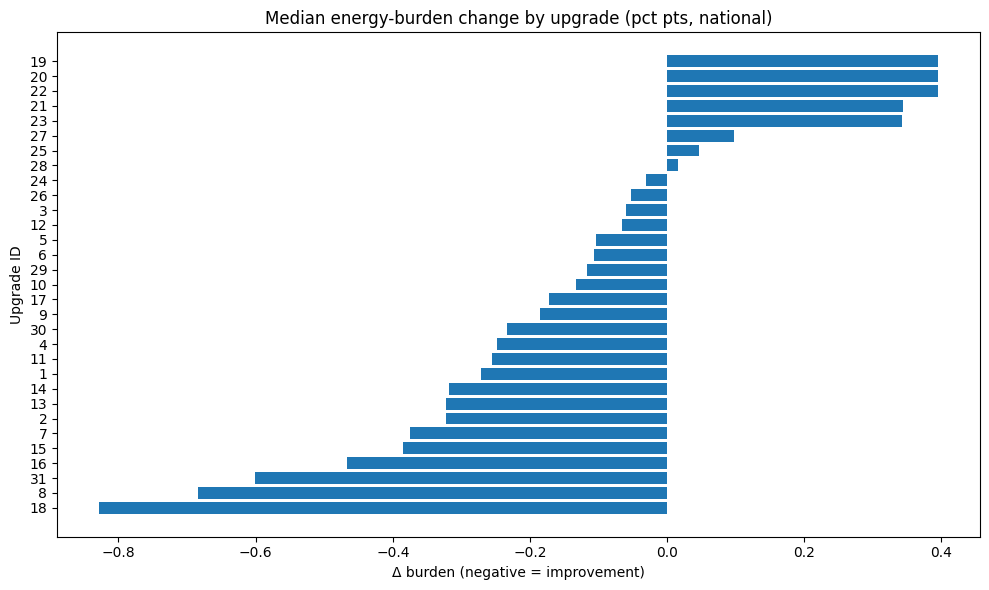

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate 'top' as it's needed for both the plot and the legend
top = (rankings.groupby(["upgrade_id", "upgrade_name"])
       .apply(lambda d: wmedian(d["d_burden_wmed"], d["weighted_homes"]), include_groups=False)
       .sort_values(ascending=True)) # Ensure sorted for consistent legend order

fig, ax = plt.subplots(1, 1, figsize=(10, 6)) # Only one subplot now

# Plotting with upgrade_id on y-axis and median burden change as width
# Convert upgrade_id to string for y-axis labels
ax.barh(y=top.index.get_level_values('upgrade_id').astype(str), width=top.values, color="tab:blue")
ax.set_title("Median energy-burden change by upgrade (pct pts, national)")
ax.set_xlabel("Δ burden (negative = improvement)")
ax.set_ylabel("Upgrade ID")

plt.tight_layout() # Layout for just this plot
plt.show()

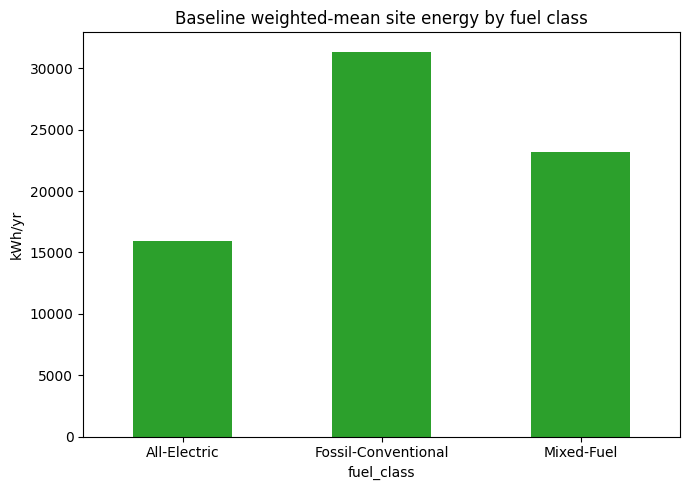

In [ ]:
import matplotlib.pyplot as plt

fig_fc, ax_fc = plt.subplots(1, 1, figsize=(7, 5))
fc = base.groupby("fuel_class").apply(lambda d: wmean(d[SITE], d[W]), include_groups=False)
fc.plot.bar(ax=ax_fc, color="tab:green")
ax_fc.set_title("Baseline weighted-mean site energy by fuel class")
ax_fc.set_ylabel("kWh/yr")
plt.xticks(rotation=0, ha='center') # Ensure x-axis labels are horizontal
plt.tight_layout()
plt.show()

### Upgrade ID to Name Legend (Ordered by Improvement)

| Upgrade ID | Upgrade Name |
| :--------- | :----------- |
| 18 | Package - Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes with Air Sealing with Attic Floor Insulation with Duct Sealing |
| 8 | Variable-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes |
| 31 | Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes, General Air Sealing, Attic Floor Insulation, and Duct Sealing |
| 16 | Air Sealing + Attic Floor Insulation + Duct sealing + Drill and Fill Wall Insulation |
| 15 | Air Sealing + Attic Floor Insulation + Duct sealing |
| 7 | Dual-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes |
| 2 | Propane or Fuel Oil Furnace 95% AFUE |
| 13 | Duct Sealing and Insulation |
| 14 | Drill and Fill Wall Insulation with Air Sealing |
| 1 | Natural Gas Furnace 95% AFUE for All Dwellings with Ducts |
| 11 | Air Sealing |
| 4 | Typical Cold Climate Ducted Air Source Heat Pump with Detailed Performance Data |
| 30 | General Air Sealing, Attic Floor Insulation, and Duct Sealing |
| 29 | General Air Sealing |
| 5 | Dual Fuel Heating System |
| 6 | Single-Speed Geothermal Heat Pump with Thermally Enhanced Grout and Pipes |
| 10 | High Efficiency Natural Gas Tankless Water Heater |
| 9 | Heat Pumps Water Water Heater |
| 17 | EnergyStar Windows |
| 12 | Attic Floor Insulation for Unfinished Attics |
| 3 | Minimum Efficiency Boilers, Furnaces, and Air Conditioners Circa 2025 |
| 24 | HVAC Demand Flexibility - On-peak Load Shedding, 2F Offset |
| 28 | HVAC Demand Flexibility - Pre-peak Load Shifting, 2F Offset, 1hr Pre-peak Duration |
| 25 | HVAC Demand Flexibility - Pre-peak Load Shifting, 2F Offset, 4hr Pre-peak Duration |
| 26 | HVAC Demand Flexibility - On-peak Load Shedding, 4F Offset |
| 27 | HVAC Demand Flexibility - Pre-peak Load Shifting, 4F Offset, 4hr Pre-peak Duration |
| 21 | Efficient Electric Vehicle Adoption with Level 2 Charging |
| 23 | Efficient Electric Vehicle Adoption with Level 2 Charging and Demand Flexibility |
| 22 | Electric Vehicle Adoption with Level 2 Charging and Demand Flexibility |
| 20 | Electric Vehicle Adoption with Level 2 Charging |
| 19 | Electric Vehicle Adoption with Level 1 Charging |


**Caveats:** simulated (not metered) outcomes; statistically assigned incomes/demographics; bills embed regional rate differences and PV net metering (a bill gap ≠ an efficiency gap); site-kWh comparisons flatter heat pumps by construction (COP > 1), so report bills and fuel-specific energy alongside site energy; Phase 2's cross-sectional gaps remain associational — the same-home counterfactual deltas are the causal estimate; with ~550k weighted simulated samples, report effect sizes and distributions rather than significance tests.

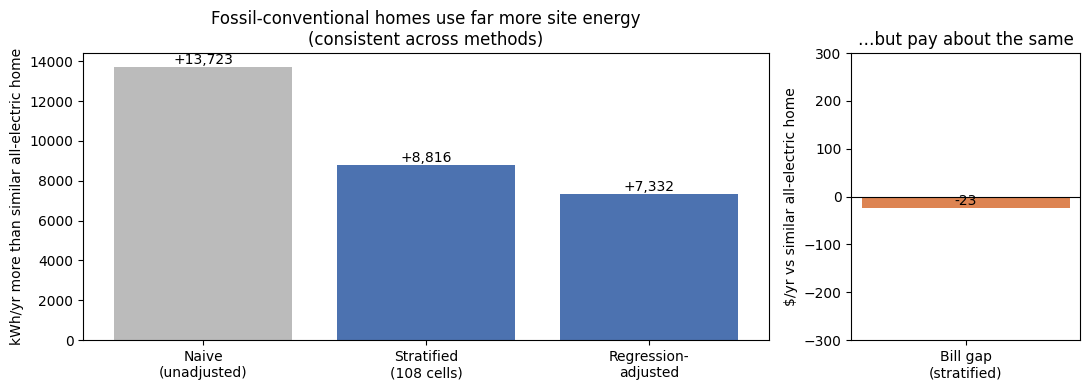

In [ ]:
naive = base.groupby("fuel_class").apply(lambda d: wmedian(d[SITE], d[W]), include_groups=False)
energy_gap = pd.Series({
    "Naive\n(unadjusted)": naive["Fossil-Conventional"] - naive["All-Electric"],
    "Stratified\n(108 cells)": wmedian(gaps["site_kwh_gap_fossil_vs_elec"], w_common),
    "Regression-\nadjusted": m.params["C(fuel_class, Treatment('All-Electric'))[T.Fossil-Conventional]"],
})
bill_gap = wmedian(gaps["bill_gap_fossil_vs_elec"], w_common)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 1]})
axes[0].bar(energy_gap.index, energy_gap.values, color=["#bbbbbb", "#4c72b0", "#4c72b0"])
axes[0].set_ylabel("kWh/yr more than similar all-electric home")
axes[0].set_title("Fossil-conventional homes use far more site energy\n(consistent across methods)")
for i, v in enumerate(energy_gap.values):
    axes[0].text(i, v, f"+{v:,.0f}", ha="center", va="bottom")

axes[1].bar(["Bill gap\n(stratified)"], [bill_gap], color="#dd8452")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("$/yr vs similar all-electric home")
axes[1].set_ylim(-300, 300)
axes[1].set_title("…but pay about the same")
axes[1].text(0, bill_gap, f"{bill_gap:+,.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

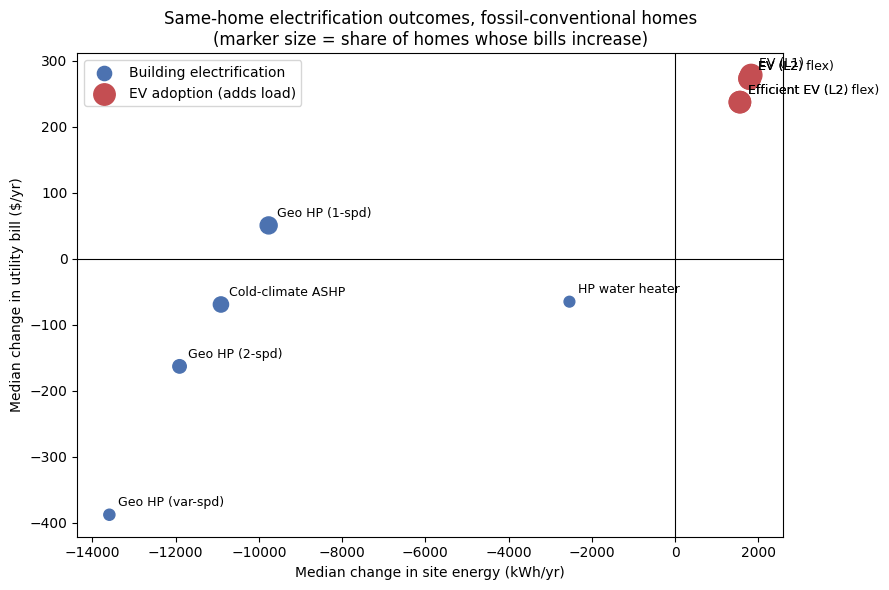

In [ ]:
cfc = counterfactual.reset_index()
cfc = cfc[cfc["fuel_class"] == "Fossil-Conventional"].copy()
cfc["uid"] = cfc["upgrade_id"].astype(float).astype(int)
cfc["label"] = cfc["uid"].map(SHORT)
cfc["kind"] = np.where(cfc["uid"] >= 19, "EV adoption (adds load)", "Building electrification")

fig, ax = plt.subplots(figsize=(9, 6))
colors = {"Building electrification": "#4c72b0", "EV adoption (adds load)": "#c44e52"}
for kind, d in cfc.groupby("kind"):
    ax.scatter(d["d_site_kwh_wmed"], d["d_bill_usd_wmed"],
               s=200 * d["share_bill_increases"] + 40, color=colors[kind], label=kind, zorder=3)
    for _, r in d.iterrows():
        ax.annotate(r["label"], (r["d_site_kwh_wmed"], r["d_bill_usd_wmed"]),
                    xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.axhline(0, color="black", lw=0.8); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Median change in site energy (kWh/yr)")
ax.set_ylabel("Median change in utility bill ($/yr)")
ax.set_title("Same-home electrification outcomes, fossil-conventional homes\n(marker size = share of homes whose bills increase)")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

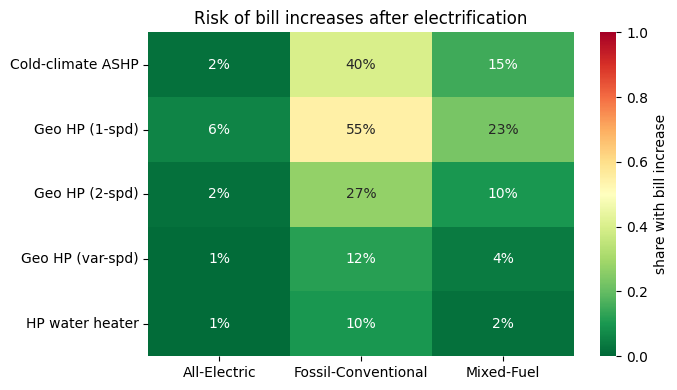

In [ ]:
risk = (counterfactual.reset_index()
        .assign(uid=lambda d: d["upgrade_id"].astype(float).astype(int))
        .assign(label=lambda d: d["uid"].map(SHORT))
        .query("uid < 19")  # building measures only
        .pivot_table(index="label", columns="fuel_class", values="share_bill_increases"))

fig, ax = plt.subplots(figsize=(7, 0.5 * len(risk) + 1.5))
sns.heatmap(risk, annot=True, fmt=".0%", cmap="RdYlGn_r", vmin=0, vmax=1,
            cbar_kws={"label": "share with bill increase"}, ax=ax)
ax.set_title("Risk of bill increases after electrification")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout(); plt.show()

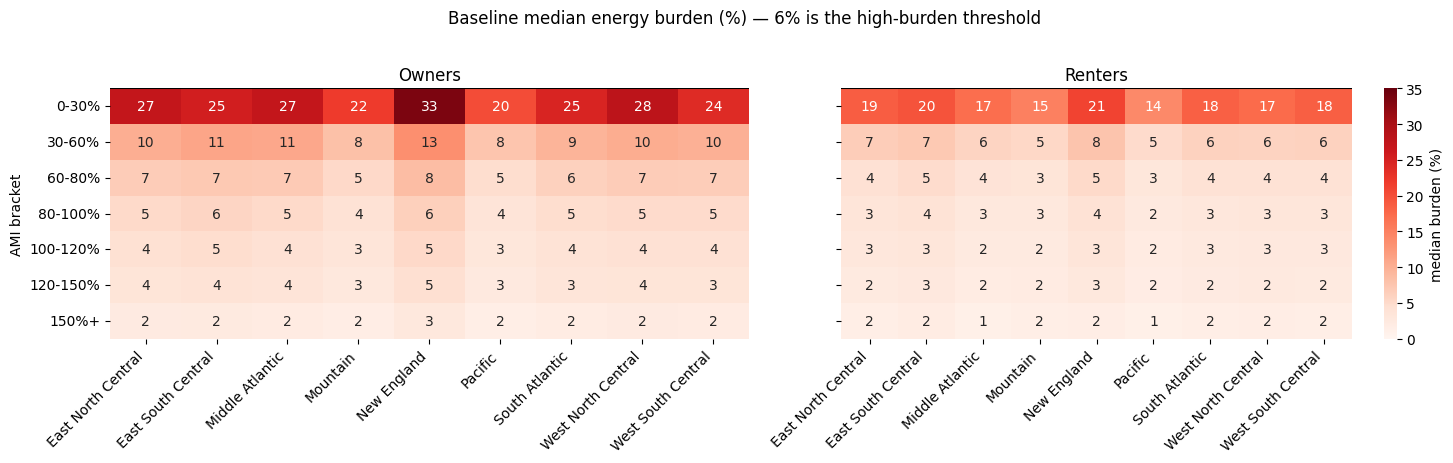

In [ ]:
bt = (pop.groupby(GROUPS, observed=True)
      .apply(lambda d: wmedian(d[BURDEN_COL], d[W]), include_groups=False)
      .rename("burden").reset_index())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=True)
for ax, ten in zip(axes, ["Owner", "Renter"]):
    piv = (bt[bt["in.tenure"] == ten]
           .pivot(index="in.area_median_income", columns="in.census_division", values="burden")
           .reindex(AMI_ORDER))
    sns.heatmap(piv, annot=True, fmt=".0f", cmap="Reds", vmin=0, vmax=35,
                cbar=(ten == "Renter"), cbar_kws={"label": "median burden (%)"}, ax=ax)
    ax.axhline(0, color="black")
    ax.set_title(f"{ten}s"); ax.set_xlabel(""); ax.set_ylabel("AMI bracket" if ten == "Owner" else "")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate x-axis labels
fig.suptitle("Baseline median energy burden (%) — 6% is the high-burden threshold", y=1.02)
plt.tight_layout(); plt.show()

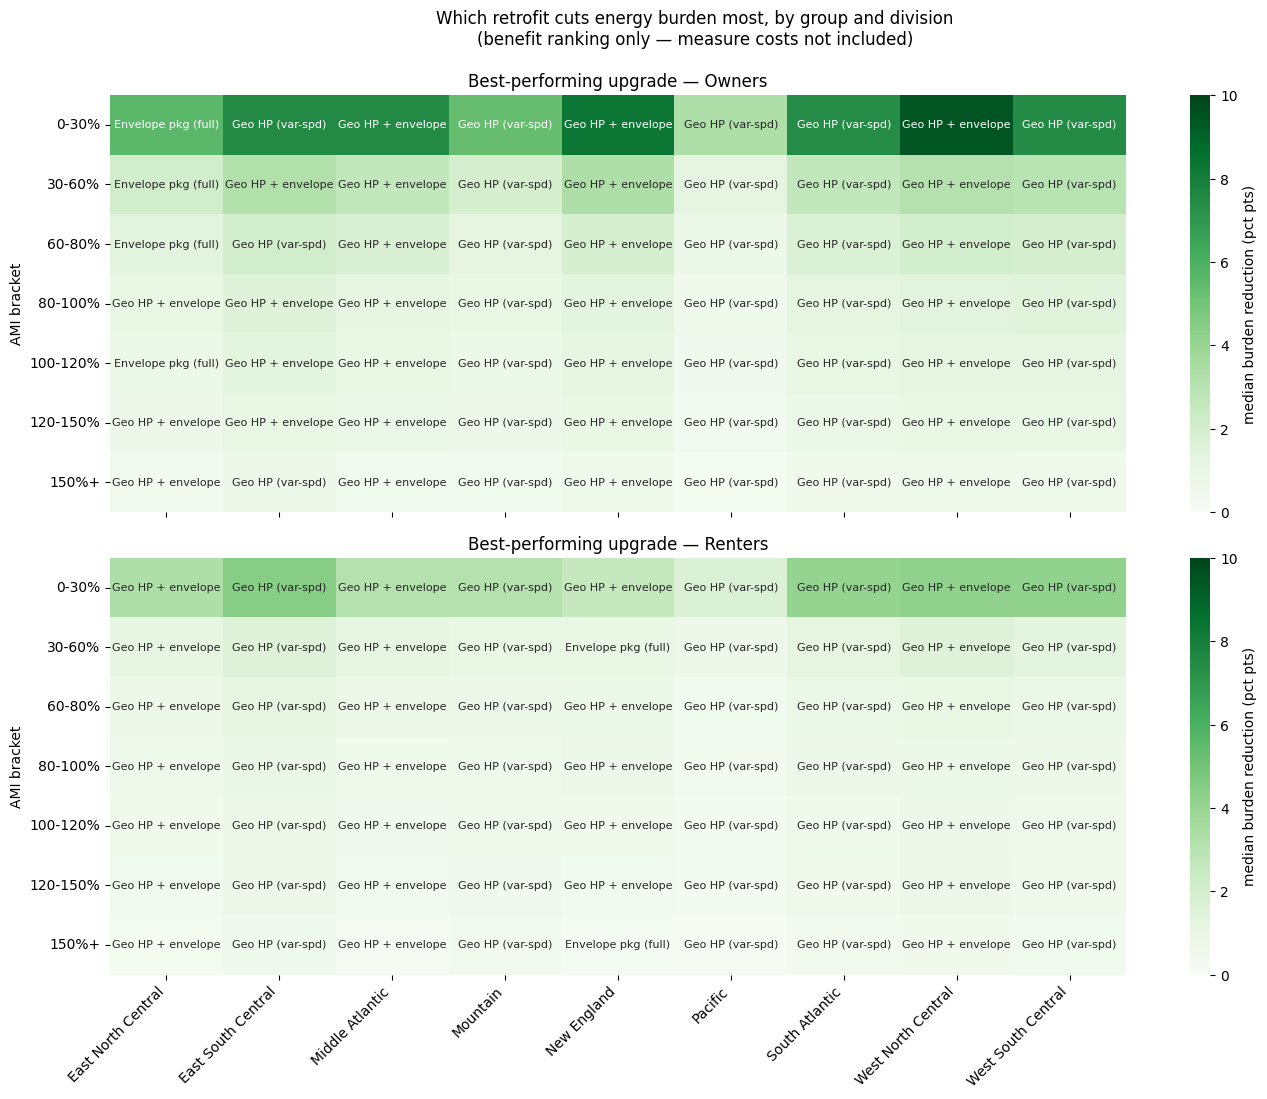

In [ ]:
bm = best.copy()
bm["uid"] = bm["best_upgrade"].astype(float).astype(int)
bm["label"] = bm["uid"].map(SHORT)

fig, axes = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
for ax, ten in zip(axes, ["Owner", "Renter"]):
    d = bm[bm["in.tenure"] == ten]
    mag = (d.pivot(index="in.area_median_income", columns="in.census_division",
                   values="median_burden_change_pct").reindex(AMI_ORDER))
    lab = (d.pivot(index="in.area_median_income", columns="in.census_division",
                   values="label").reindex(AMI_ORDER))
    sns.heatmap(-mag, annot=lab, fmt="", cmap="Greens", vmin=0, vmax=10,
                cbar_kws={"label": "median burden reduction (pct pts)"},
                annot_kws={"fontsize": 8}, ax=ax)
    ax.set_title(f"Best-performing upgrade — {ten}s")
    ax.set_xlabel(""); ax.set_ylabel("AMI bracket")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # Rotate x-axis labels
fig.suptitle("Which retrofit cuts energy burden most, by group and division\n(benefit ranking only — measure costs not included)", y=0.995)
plt.tight_layout(); plt.show()

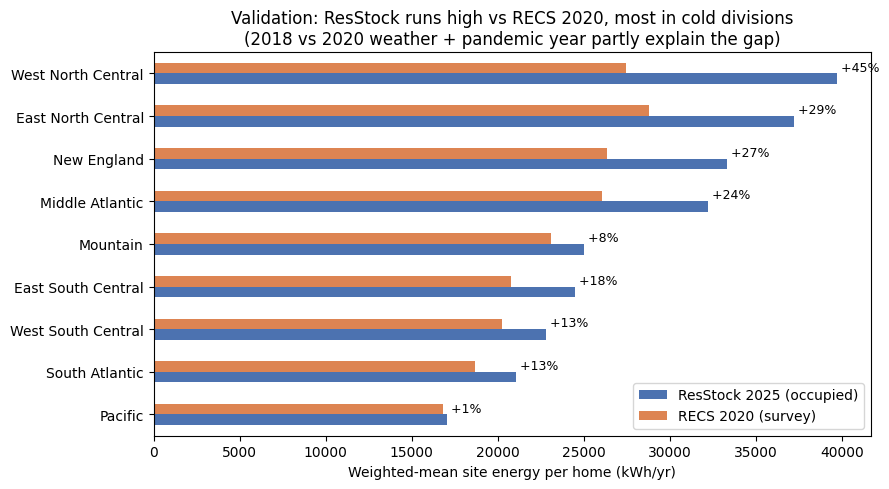

In [ ]:
recs_cmp = recs_g.copy()
mountain = recs_cmp[recs_cmp.index.str.startswith("Mountain")]
recs_cmp = recs_cmp[~recs_cmp.index.str.startswith("Mountain")]
recs_cmp["Mountain"] = mountain.mean()  # RECS splits Mountain; simple average for display

val = pd.DataFrame({"ResStock 2025 (occupied)": rs_g, "RECS 2020 (survey)": recs_cmp}).dropna()
val = val.sort_values("ResStock 2025 (occupied)")

ax = val.plot.barh(figsize=(9, 5), color=["#4c72b0", "#dd8452"])
ax.set_xlabel("Weighted-mean site energy per home (kWh/yr)")
ax.set_title("Validation: ResStock runs high vs RECS 2020, most in cold divisions\n(2018 vs 2020 weather + pandemic year partly explain the gap)")
for i, (_, r) in enumerate(val.iterrows()):
    pct = r.iloc[0] / r.iloc[1] - 1
    ax.text(r.iloc[0], i + 0.15, f" +{pct:.0%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()